# Week 10 — Future Work 3 (FW3): MSR-VTT Video Captioning Extension

**Dissertation:** Advance Multimodel Generative Artificial Intelligence — Controllable Image Captioning with Large Vision-Language Models
**Author:** Avinash Sahu  |  **Supervisor:** Varun Ojha

**Goal (interim report, FW3):** extend the controllability techniques to **MSR-VTT video
captioning** and compare controllability across the *image* and *video* modalities
(Xu et al., CVPR 2016).

**Why this notebook is different from FW2/FW4/FW5.** MSR-VTT is a *video* dataset (10,000 clips,
~20 reference captions each), not COCO — so this is the one future-work item that cannot run on
your 1,000-image COCO set. LLaVA-1.6-Mistral-7B is an image model, so we extend it to video the
standard way: **uniformly sample frames from each clip, caption the representative (middle) frame
with the same prompt techniques, and evaluate against the clip's reference captions.**

It reuses every Week 1–8 convention it can (model loader, `generate_caption()`, BLEU/CLIP
functions, `' | '` caption format, `RANDOM_SEED = 42`, results-table schema) and saves results to
the same `results/` folder so an image-vs-video comparison drops straight in.

**Data setup (one-time).** Place an MSR-VTT subset on your Drive:
- `data/msrvtt/annotations/test_videodatainfo.json`  (or `train_val_videodatainfo.json`)
- `data/msrvtt/videos/`  containing the `.mp4` clips (e.g. `video7010.mp4`)

The captions JSON is small and freely available; the videos are large, so a subset (e.g. 100
clips) is fine. The notebook automatically uses whatever clips are present.


In [1]:
# ── CELL 1 — Mount Google Drive ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')


Mounted at /content/drive
Drive mounted.


In [2]:
# ── CELL 2 — Install packages ─────────────────────────────────────────────
!pip install -q --upgrade accelerate
!pip install -q sentencepiece nltk opencv-python-headless
import nltk
nltk.download('punkt', quiet=True); nltk.download('wordnet', quiet=True)
import transformers, cv2
print(f'transformers : {transformers.__version__} | opencv : {cv2.__version__}')
print('Packages ready. No restart needed.')


transformers : 5.12.1 | opencv : 4.13.0
Packages ready. No restart needed.


In [3]:
# ── CELL 3 — Paths and config ─────────────────────────────────────────────
import os
BASE          = '/content/drive/MyDrive/dissertation_final'
MSRVTT_DIR    = f'{BASE}/data/msrvtt'
MSRVTT_VIDEOS = f'{MSRVTT_DIR}/videos'
MSRVTT_ANN    = f'{MSRVTT_DIR}/annotations/test_videodatainfo.json'   # or train_val_videodatainfo.json
RESULTS_DIR   = f'{BASE}/results'
MODEL_CACHE   = f'{BASE}/models/llava_cache'

N_VIDEOS    = 100        # subset of clips to evaluate (uses fewer if fewer are present)
N_FRAMES    = 3          # frames sampled per clip (CLIP averaged over them)
MAX_REFS    = 20         # MSR-VTT reference captions per clip
RANDOM_SEED = 42

os.makedirs(RESULTS_DIR, exist_ok=True)
print('Required:')
print(f'  {"OK" if os.path.exists(MSRVTT_ANN) else "MISSING"} : annotations -> {MSRVTT_ANN}')
print(f'  {"OK" if os.path.isdir(MSRVTT_VIDEOS) else "MISSING"} : video folder -> {MSRVTT_VIDEOS}')
if os.path.isdir(MSRVTT_VIDEOS):
    n = len([f for f in os.listdir(MSRVTT_VIDEOS) if f.lower().endswith(('.mp4','.avi','.webm','.mkv'))])
    print(f'  video files present: {n}')
if not (os.path.exists(MSRVTT_ANN) and os.path.isdir(MSRVTT_VIDEOS)):
    print('\nPlace the MSR-VTT captions JSON and a subset of .mp4 clips on Drive (see notebook header).')


Required:
  MISSING : annotations -> /content/drive/MyDrive/dissertation_final/data/msrvtt/annotations/test_videodatainfo.json
  OK : video folder -> /content/drive/MyDrive/dissertation_final/data/msrvtt/videos
  video files present: 200

Place the MSR-VTT captions JSON and a subset of .mp4 clips on Drive (see notebook header).


In [4]:
# ── CELL 4 — GPU check ────────────────────────────────────────────────────
import torch
if torch.cuda.is_available():
    print('GPU :', torch.cuda.get_device_name(0),
          f'| VRAM {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB',
          f'| CUDA {torch.version.cuda} | torch {torch.__version__}')
else:
    print('No GPU. Runtime -> Change runtime type -> A100/T4 GPU.')


GPU : NVIDIA A100-SXM4-80GB | VRAM 85.1 GB | CUDA 12.8 | torch 2.11.0+cu128


In [5]:
# ── CELL 5 — Imports ──────────────────────────────────────────────────────
import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, cv2
from PIL import Image
from tqdm import tqdm
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
from transformers import LlavaNextForConditionalGeneration, CLIPProcessor, CLIPModel
import transformers
if tuple(int(x) for x in transformers.__version__.split('.')[:2]) >= (4, 38):
    from transformers import AutoProcessor as LlavaProcessor
else:
    from transformers import LlavaNextProcessor as LlavaProcessor
print('Imports done.')


Imports done.


In [6]:
# ── CELL 6 — Load LLaVA (same loader as Week 3) ──────────────────────────
def load_llava():
    load_from = MODEL_CACHE if os.path.exists(f'{MODEL_CACHE}/config.json') else 'llava-hf/llava-v1.6-mistral-7b-hf'
    print(f'Loading from: {load_from}')
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    processor = LlavaProcessor.from_pretrained(load_from, use_fast=False)
    model     = LlavaNextForConditionalGeneration.from_pretrained(
        load_from, torch_dtype=torch.float16, device_map='auto', low_cpu_mem_usage=True)
    model.eval()
    print(f'Loaded on {next(model.parameters()).device} | dtype: {next(model.parameters()).dtype}')
    return processor, model

processor, model = load_llava()
print('LLaVA ready.')


Loading from: /content/drive/MyDrive/dissertation_final/models/llava_cache


[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

Loaded on cuda:0 | dtype: torch.float16
LLaVA ready.


In [7]:
# ── CELL 7 — generate_caption + BLEU/CLIP metrics (identical to Week 3) ───
def generate_caption(processor, model, image, prompt='Describe this image in detail.', max_new_tokens=100):
    conv   = [{'role':'user','content':[{'type':'image'},{'type':'text','text':prompt}]}]
    text   = processor.apply_chat_template(conv, add_generation_prompt=True)
    inputs = processor(images=image, text=text, return_tensors='pt').to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, temperature=None, top_p=None)
    return processor.batch_decode(out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0].strip()

_clip_proc, _clip_model = None, None
def get_clip():
    global _clip_proc, _clip_model
    if _clip_model is None:
        _clip_proc  = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
        _clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(
            'cuda' if torch.cuda.is_available() else 'cpu').eval()
    return _clip_proc, _clip_model

def compute_sentence_bleu(gen, refs):
    s = SmoothingFunction().method1
    return round(sentence_bleu([r.lower().split() for r in refs], gen.lower().split(), smoothing_function=s), 4)

def compute_bleu(generated, references):
    s = SmoothingFunction().method1
    hyps = [g.lower().split() for g in generated]
    refs = [[r.lower().split() for r in rs] for rs in references]
    return {'bleu_1': round(corpus_bleu(refs, hyps, weights=(1,0,0,0), smoothing_function=s), 4),
            'bleu_4': round(corpus_bleu(refs, hyps, weights=(.25,.25,.25,.25), smoothing_function=s), 4)}

def compute_clip_scores_batch(images, captions, batch_size=16):
    proc, mdl = get_clip(); dev, scores = next(mdl.parameters()).device, []
    for i in range(0, len(images), batch_size):
        inp = proc(text=captions[i:i+batch_size], images=images[i:i+batch_size],
                   return_tensors='pt', padding=True, truncation=True, max_length=77)
        inp = {k: v.to(dev) for k, v in inp.items()}
        with torch.no_grad():
            out = mdl(**inp)
            ie = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
            te = out.text_embeds  / out.text_embeds.norm(dim=-1,  keepdim=True)
            scores.extend((ie*te).sum(dim=-1).tolist())
    return [round(s, 4) for s in scores]

print('generate_caption + metrics ready.')


generate_caption + metrics ready.


In [8]:
# ── CELL 7b — One-time MSR-VTT download & setup (run once; then it skips) ──
# Downloads the Frozen-in-Time mirror (videos + annotations, ~6 GB) to local
# Colab disk, then copies a SUBSET of clips + the annotation JSON to Drive.
import os, glob

os.makedirs(f'{MSRVTT_DIR}/annotations', exist_ok=True)
os.makedirs(MSRVTT_VIDEOS, exist_ok=True)
ann_single = f'{MSRVTT_DIR}/annotations/MSR_VTT.json'
SUBSET_N   = 200          # how many clips to copy to Drive (>= N_VIDEOS in Cell 3)

have_videos = len(glob.glob(f'{MSRVTT_VIDEOS}/*.mp4')) >= 1
have_ann    = os.path.exists(MSRVTT_ANN) or os.path.exists(ann_single)

if have_videos and have_ann:
    print('MSR-VTT already staged on Drive — skipping download.')
else:
    print('Downloading MSR-VTT mirror (~6 GB) to local Colab disk...')
    !wget -q --show-progress https://www.robots.ox.ac.uk/~maxbain/frozen-in-time/data/MSRVTT.zip -O /content/MSRVTT.zip
    print('Unzipping locally...')
    !unzip -q /content/MSRVTT.zip -d /content/msrvtt_raw

    src_vid = '/content/msrvtt_raw/MSRVTT/videos/all'
    src_ann = '/content/msrvtt_raw/MSRVTT/annotation/MSR_VTT.json'

    # copy the annotation (small) and a subset of videos to Drive
    !cp -n "{src_ann}" "{ann_single}"
    vids = sorted(glob.glob(f'{src_vid}/*.mp4'))[:SUBSET_N]
    print(f'Copying {len(vids)} clips to Drive...')
    for v in vids:
        dst = os.path.join(MSRVTT_VIDEOS, os.path.basename(v))
        if not os.path.exists(dst):
            !cp "{v}" "{dst}"
    !rm -f /content/MSRVTT.zip
    print('Done staging subset to Drive.')

print('videos on Drive :', len(glob.glob(f'{MSRVTT_VIDEOS}/*.mp4')))
print('annotation file :', ann_single if os.path.exists(ann_single) else MSRVTT_ANN)

MSR-VTT already staged on Drive — skipping download.
videos on Drive : 200
annotation file : /content/drive/MyDrive/dissertation_final/data/msrvtt/annotations/MSR_VTT.json


In [9]:
# ── CELL 8 — Load MSR-VTT captions and match to available video files ────
# Accept either the original test_videodatainfo.json or the Frozen-in-Time MSR_VTT.json
ann_path = MSRVTT_ANN if os.path.exists(MSRVTT_ANN) else f'{MSRVTT_DIR}/annotations/MSR_VTT.json'
print('Using annotation file:', ann_path)
with open(ann_path) as f:
    ann = json.load(f)

refs_by_vid = {}
# Changed 'sentences' to 'annotations' and 'video_id' to 'image_id' for MSR_VTT.json format
for s in ann.get('annotations', []):
    refs_by_vid.setdefault(s['image_id'], []).append(s['caption'].strip().replace('\n', ' '))

# Map available video files (by filename stem) to their path
exts = ('.mp4', '.avi', '.webm', '.mkv')
files = {os.path.splitext(f)[0]: os.path.join(MSRVTT_VIDEOS, f)
         for f in os.listdir(MSRVTT_VIDEOS) if f.lower().endswith(exts)}

# Working set = clips that have both a video file AND reference captions
vids = sorted(set(files) & set(refs_by_vid))
rng = np.random.default_rng(RANDOM_SEED); rng.shuffle(vids)
vids = vids[:N_VIDEOS]

work = pd.DataFrame([{'video_id': v, 'video_path': files[v],
                      'captions': ' | '.join(refs_by_vid[v][:MAX_REFS])} for v in vids])
print(f'Clips available with captions: {len(set(files) & set(refs_by_vid))}')
print(f'Evaluating on: {len(work)} clips')
work.head(3)


Using annotation file: /content/drive/MyDrive/dissertation_final/data/msrvtt/annotations/MSR_VTT.json
Clips available with captions: 200
Evaluating on: 100 clips


,video_id,video_path,captions
0,video1134,/content/drive/MyDrive/dissertation_final/data...,a clip of a fighting video game | a fighting c...
1,video1020,/content/drive/MyDrive/dissertation_final/data...,a guy talks about the furniture in his room li...
2,video1100,/content/drive/MyDrive/dissertation_final/data...,four tomatoes on a vine are on a white plate a...


In [10]:
# ── CELL 9 — Frame sampling (uniform frames + representative middle frame) ─
def sample_frames(video_path, n_frames=N_FRAMES):
    """Return up to n_frames uniformly sampled PIL frames from a video."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
    frames = []
    if total <= 0:                       # fallback: read sequentially
        ok, fr = cap.read()
        while ok:
            frames.append(fr); ok, fr = cap.read()
        cap.release()
        idxs = np.linspace(0, max(len(frames)-1,0), n_frames).astype(int) if frames else []
        return [Image.fromarray(cv2.cvtColor(frames[i], cv2.COLOR_BGR2RGB)) for i in idxs]
    idxs = np.linspace(0, total-1, n_frames).astype(int)
    out = []
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i)); ok, fr = cap.read()
        if ok: out.append(Image.fromarray(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB)))
    cap.release()
    return out

def representative_frame(frames):
    return frames[len(frames)//2] if frames else None

# smoke test on one clip
_f = sample_frames(work.iloc[0]['video_path'])
print(f"Sampled {len(_f)} frames from {work.iloc[0]['video_id']}; "
      f"representative size = {representative_frame(_f).size if _f else 'none'}")


Sampled 3 frames from video1134; representative size = (320, 240)


In [11]:
# ── CELL 10 — Technique conditions (same prompt texts as Weeks 3–4) ──────
# Video adds a temporal dimension, so we apply the conditions most relevant to motion/content.
CONDITIONS = {
    'baseline':     'Describe this image in detail.',
    'action_focus': 'Describe what is happening in this image. Focus on any actions, movements, or events taking place.',
    'expert_coco':  ('You are an expert annotator working on the MS COCO dataset. Write a single descriptive '
                     'sentence that accurately describes the main subject and action in this image, following '
                     'the style of professional COCO human annotations. Be concise, accurate, and grounded only '
                     'in what is visible.'),
}
print('Conditions to run on video frames:')
for k in CONDITIONS: print('  -', k)


Conditions to run on video frames:
  - baseline
  - action_focus
  - expert_coco


In [12]:
# ── CELL 11 — Caption clips (representative frame) for each condition ────
# For each clip: sample frames, caption the middle frame with each technique,
# BLEU-4 vs the clip's references, CLIP averaged over the sampled frames.
for cond, prompt in CONDITIONS.items():
    out_csv = f'{RESULTS_DIR}/week10_fw3_{cond}.csv'
    if os.path.exists(out_csv):
        print(f'[skip] {cond} done -> {os.path.basename(out_csv)}'); continue
    print(f'\n=== MSR-VTT | {cond} ===')
    records = []
    for _, row in tqdm(work.iterrows(), total=len(work), desc=cond):
        frames = sample_frames(row['video_path'])
        if not frames:
            continue
        rep = representative_frame(frames)
        gen = generate_caption(processor, model, rep, prompt=prompt)
        refs = row['captions'].split(' | ')
        # CLIP averaged across the sampled frames (caption vs each frame)
        clip_vals = compute_clip_scores_batch(frames, [gen]*len(frames))
        records.append({'video_id': row['video_id'], 'video_path': row['video_path'],
                        'generated': gen, 'references': row['captions'],
                        'bleu4': compute_sentence_bleu(gen, refs),
                        'clip_score': round(float(np.mean(clip_vals)), 4),
                        'n_frames': len(frames)})
    pd.DataFrame(records).to_csv(out_csv, index=False)
    print(f'  saved -> {out_csv}  ({len(records)} clips)')
print('\nAll conditions complete.')


[skip] baseline done -> week10_fw3_baseline.csv
[skip] action_focus done -> week10_fw3_action_focus.csv
[skip] expert_coco done -> week10_fw3_expert_coco.csv

All conditions complete.


In [13]:
# ── CELL 12 — Aggregate FW3 + image-vs-video controllability comparison ──
rows = []
for cond in CONDITIONS:
    p = f'{RESULTS_DIR}/week10_fw3_{cond}.csv'
    if not os.path.exists(p): continue
    df = pd.read_csv(p)
    bleu = compute_bleu(df['generated'].tolist(), [str(r).split(' | ') for r in df['references']])
    rows.append({'Technique': cond, 'BLEU-1': bleu['bleu_1'], 'BLEU-4': bleu['bleu_4'],
                 'CLIP score (mean)': round(df['clip_score'].mean(), 4),
                 'CLIP score (std)':  round(df['clip_score'].std(),  4), 'N': len(df)})
fw3 = pd.DataFrame(rows)
if len(fw3):
    base = fw3[fw3['Technique'] == 'baseline']
    if len(base):
        b4, bc = base['BLEU-4'].values[0], base['CLIP score (mean)'].values[0]
        fw3['Delta BLEU-4']     = (fw3['BLEU-4'] - b4).round(4)
        fw3['Delta CLIP score'] = (fw3['CLIP score (mean)'] - bc).round(4)
fw3.to_csv(f'{RESULTS_DIR}/FINAL_results_fw3.csv', index=False)
print('Saved: FINAL_results_fw3.csv\n')
print('='*80); print('FW3 — MSR-VTT video captioning (representative frame)'); print('='*80)
print(fw3.to_string(index=False))

# Image (COCO) vs video (MSR-VTT) controllability, where conditions overlap
img_path = f'{RESULTS_DIR}/FINAL_results_table.csv'
if os.path.exists(img_path) and len(fw3):
    img = pd.read_csv(img_path); img['key'] = img['Technique'].str.lower()
    vid = fw3.copy(); vid['key'] = vid['Technique'].str.lower()
    m = img.merge(vid, on='key', suffixes=(' [image/COCO]', ' [video/MSR-VTT]'), how='inner')
    cols = [c for c in ['key','BLEU-4 [image/COCO]','BLEU-4 [video/MSR-VTT]',
            'CLIP score (mean) [image/COCO]','CLIP score (mean) [video/MSR-VTT]'] if c in m.columns]
    if len(m):
        print('\nControllability across modalities (matching conditions):')
        print(m[cols].to_string(index=False))


Saved: FINAL_results_fw3.csv

FW3 — MSR-VTT video captioning (representative frame)
   Technique  BLEU-1  BLEU-4  CLIP score (mean)  CLIP score (std)   N  Delta BLEU-4  Delta CLIP score
    baseline  0.2045  0.0241             0.2724            0.0382 100        0.0000            0.0000
action_focus  0.2131  0.0283             0.2708            0.0356 100        0.0042           -0.0016
 expert_coco  0.4557  0.1003             0.2720            0.0407 100        0.0762           -0.0004


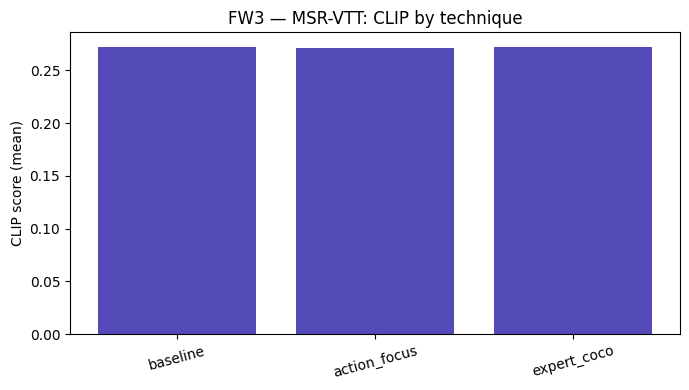

Saved figure: /content/drive/MyDrive/dissertation_final/results/week10_fw3_clip_by_technique.png

FW3 complete. Remaining future work: FW4 (BLIP-2 comparison), FW5 (hallucination rate).


In [14]:
# ── CELL 13 — Plot image vs video and finish ─────────────────────────────
if len(fw3):
    fig, ax = plt.subplots(figsize=(7,4))
    ax.bar(fw3['Technique'], fw3['CLIP score (mean)'], color='#534AB7')
    ax.set_ylabel('CLIP score (mean)'); ax.set_title('FW3 — MSR-VTT: CLIP by technique')
    plt.xticks(rotation=15); plt.tight_layout()
    out = f'{RESULTS_DIR}/week10_fw3_clip_by_technique.png'
    plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
    print('Saved figure:', out)
print('\nFW3 complete. Remaining future work: FW4 (BLIP-2 comparison), FW5 (hallucination rate).')
